# Exploratory 3 — Desc. Stats

Ditulis oleh: Atha Bintang Wahyu M.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

DATA_BERSIH = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/DATA_BERSIH")

YEARS = [2011, 2014, 2018, 2019, 2020, 2021, 2024]
adm4_files = {y: DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag.gpkg" for y in YEARS}
adm4_pca_files = {y: DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag_pca.gpkg" for y in YEARS}
# adm4_pca_csv = {y: DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag_pca.csv" for y in YEARS}

gdf_by_year = {}
gdf_pca_by_year = {}
for y in YEARS:
    p = adm4_files.get(y)
    if p and p.exists():
        gdf_by_year[y] = gpd.read_file(p)
    pp = adm4_pca_files.get(y)
    if pp and pp.exists():
        gdf_pca_by_year[y] = gpd.read_file(pp)

print("Tahun yang terbaca (dengan IUP):", list(gdf_by_year.keys()))
print("Tahun yang terbaca (dengan PCA):", list(gdf_pca_by_year.keys()))

Loaded years (with IUP): [2011, 2014, 2018, 2019, 2020, 2021, 2024]
Loaded years (with PCA): [2011, 2014, 2018, 2019, 2020, 2021, 2024]


## 1. Stats Desc Tables — Desa with IUP

In [2]:
# Desa dengan IUP by year
iup_col = "has_iup"  # 0/1 in DATA_BERSIH
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if iup_col not in g.columns:
        continue
    n_total = len(g)
    n_iup = g[iup_col].fillna(0).astype(int).sum()
    pct = 100 * n_iup / n_total if n_total else 0
    rows.append({"year": y, "n_desa": n_total, "desa_dengan_IUP": n_iup, "pct_desa_IUP": round(pct, 2)})

df_desa_iup_by_year = pd.DataFrame(rows)
df_desa_iup_by_year

,year,n_desa,desa_dengan_IUP,pct_desa_IUP
0,2011,83862,880,1.05
1,2014,81912,4846,5.92
2,2018,81912,4902,5.98
3,2019,81912,4853,5.92
4,2020,81912,4856,5.93
5,2021,81912,4830,5.90
6,2024,81912,4813,5.88


In [3]:
# one df per year
for y in [2014, 2024]:
    if y not in gdf_by_year:
        continue
    g = gdf_by_year[y]
    if "has_iup" not in g.columns:
        continue
    tab = pd.DataFrame({
        "has_iup": [0, 1],
        "label": ["Tidak ada IUP", "Desa dengan IUP"],
        "n_desa": [ (g["has_iup"] == 0).sum(), (g["has_iup"] == 1).sum() ],
    })
    tab["pct"] = (100 * tab["n_desa"] / tab["n_desa"].sum()).round(2)
    print(f"--- Tahun {y} ---")
    display(tab)
    print()

--- Year 2014 ---


,has_iup,label,n_desa,pct
0,0,Tidak ada IUP,77066,94.08
1,1,Desa dengan IUP,4846,5.92



--- Year 2024 ---


,has_iup,label,n_desa,pct
0,0,Tidak ada IUP,77099,94.12
1,1,Desa dengan IUP,4813,5.88


## 2. IUP peta (2014 & 2024)


In [4]:
# Helper
def get_admin_boundaries(gdf, level="ADM2"):
    for col in ["ADM2_PCODE", "ADM2_EN", "NAMA_KAB", "ADM3_PCODE"]:
        if col in gdf.columns:
            by = "ADM2_PCODE" if "ADM2_PCODE" in gdf.columns else ("NAMA_KAB" if "NAMA_KAB" in gdf.columns else "ADM3_PCODE")
            break
    else:
        by = gdf.columns[1]  # fallback
    if "ADM2_PCODE" in gdf.columns:
        admin = gdf.dissolve(by="ADM2_PCODE", aggfunc="first").reset_index()
    elif "NAMA_KAB" in gdf.columns:
        admin = gdf.dissolve(by="NAMA_KAB", aggfunc="first").reset_index()
    else:
        admin = gdf.dissolve(by=gdf.columns[1], aggfunc="first").reset_index()
    return gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=gdf.crs)

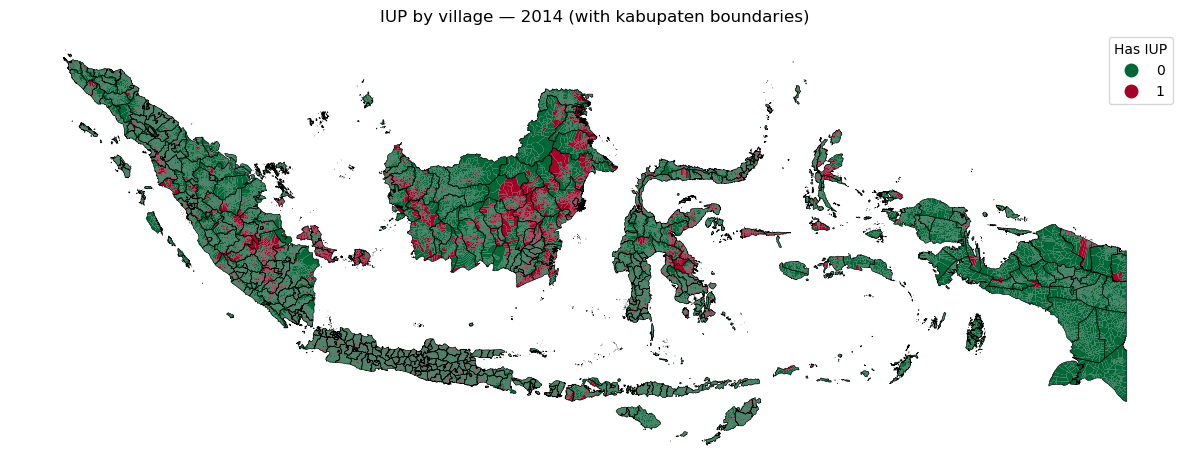

In [5]:
# with/without IUP + admin boundaries
year = 2014
if year in gdf_by_year:
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column="has_iup", categorical=True, legend=True, ax=ax, cmap="RdYlGn_r", linewidth=0.05, edgecolor="gray", legend_kwds={"title": "Ada IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Tidak ada data untuk tahun {year}")

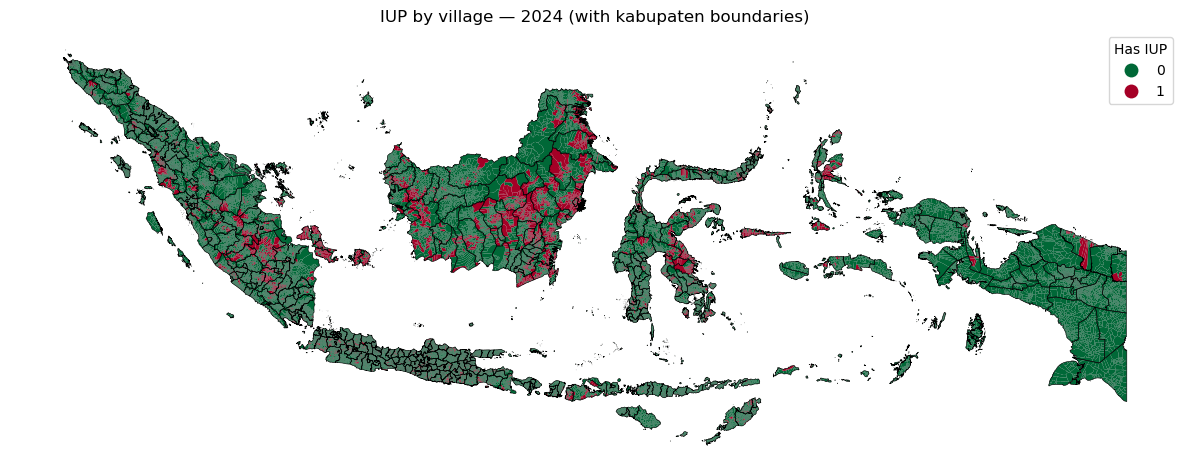

In [6]:
year = 2024
if year in gdf_by_year:
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column="has_iup", categorical=True, legend=True, ax=ax, cmap="RdYlGn_r", linewidth=0.05, edgecolor="gray", legend_kwds={"title": "Ada IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Tidak ada data untuk tahun {year}")

In [7]:
# share of villages with IUP by province
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else "ADM1_EN"
    if prov_col not in g.columns:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg["pct_iup"] = (100 * agg["n_iup"] / agg["n_desa"]).round(2)
    agg = agg.sort_values("pct_iup", ascending=False)
    print(f"Tahun {year} — % desa dengan IUP per provinsi (10 teratas):")
    display(agg.head(10))
    print()

Year 2014 — % desa dengan IUP by province (top 10):


,ADM1_EN,n_desa,n_iup,pct_iup
16,Kepulauan Bangka Belitung,391,206,52.69
14,Kalimantan Timur,1032,354,34.30
13,Kalimantan Tengah,1574,359,22.81
12,Kalimantan Selatan,2008,361,17.98
15,Kalimantan Utara,482,67,13.90
4,Daerah Istimewa Yogyakarta,438,59,13.47
20,Maluku Utara,1230,164,13.33
32,Sumatera Selatan,3264,402,12.32
11,Kalimantan Barat,2132,243,11.40
28,Sulawesi Tengah,2025,222,10.96



Year 2024 — % desa dengan IUP by province (top 10):


,NAMA_PROV,n_desa,n_iup,pct_iup
16,KEPULAUAN BANGKA BELITUNG,391,211,53.96
14,KALIMANTAN TIMUR,1012,344,33.99
13,KALIMANTAN TENGAH,1570,363,23.12
12,KALIMANTAN SELATAN,1962,345,17.58
15,KALIMANTAN UTARA,456,65,14.25
4,DI YOGYAKARTA,438,60,13.70
20,MALUKU UTARA,1176,159,13.52
11,KALIMANTAN BARAT,2132,260,12.20
32,SUMATERA SELATAN,3206,385,12.01
29,SULAWESI TENGGARA,2271,256,11.27


### IUP area (ha) 

Desa dengan IUP saja; skala log(1 + area_hectares_iup). 

In [ ]:
# IUP area (ha) map — villages with IUP only, log scale; polygons over clear Indonesia base map
try:
    import contextily as ctx
    has_ctx = True
except ImportError:
    has_ctx = False
    print("contextily tidak terpasang; peta tanpa base map. Install: pip install contextily")

for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    if "area_hectares_iup" not in g.columns:
        print(f"Tahun {year}: kolom area_hectares_iup tidak ada; skip.")
        continue
    with_iup = g[g["has_iup"] == 1].copy()
    if len(with_iup) == 0:
        print(f"Tahun {year}: tidak ada desa dengan IUP.")
        continue
    with_iup["area_log"] = np.log1p(with_iup["area_hectares_iup"].fillna(0))
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    if with_iup.crs is None:
        with_iup.set_crs(4326, inplace=True)
    # Full Indonesia extent for base map; then plot only IUP villages on top
    g_all_merc = g.to_crs(epsg=3857)
    g_merc = with_iup.to_crs(epsg=3857)
    xmin, ymin, xmax, ymax = g_all_merc.total_bounds
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    if has_ctx:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=0)
    g_merc.plot(column="area_log", legend=True, ax=ax, cmap="viridis", linewidth=0.08, edgecolor="gray",
                alpha=0.75, zorder=1, legend_kwds={"label": "log(1 + area IUP, ha)"})
    ax.set_title(f"Desa dengan IUP: log(1 + area_hectares_iup) — {year}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Peta Welfare Outcome (PCA) — 2014 dan 2024

- **Equity (Paper 1)**: first PC dari variabel ekuitas → `pca_P1_pc1`
- **Health (Paper 2)**: first PC dari variabel infrastruktur kesehatan → `pca_P2_pc1`

Maps for 2014 and 2024 dengan batas administrasi.

In [ ]:
# PCA diagnostic
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    for col in ["pca_P1_pc1", "pca_P2_pc1"]:
        if col not in g.columns:
            continue
        v = g[col].dropna()
        n_valid = len(v)
        n_total = len(g)
        pct = 100 * n_valid / n_total if n_total else 0
        print(f"{year} {col}: valid={n_valid}, total={n_total}, cakupan={pct:.1f}%")
        if len(v) > 0:
            print(f"  min={v.min():.3f}, max={v.max():.3f}, mean={v.mean():.3f}, std={v.std():.3f}")
    print()

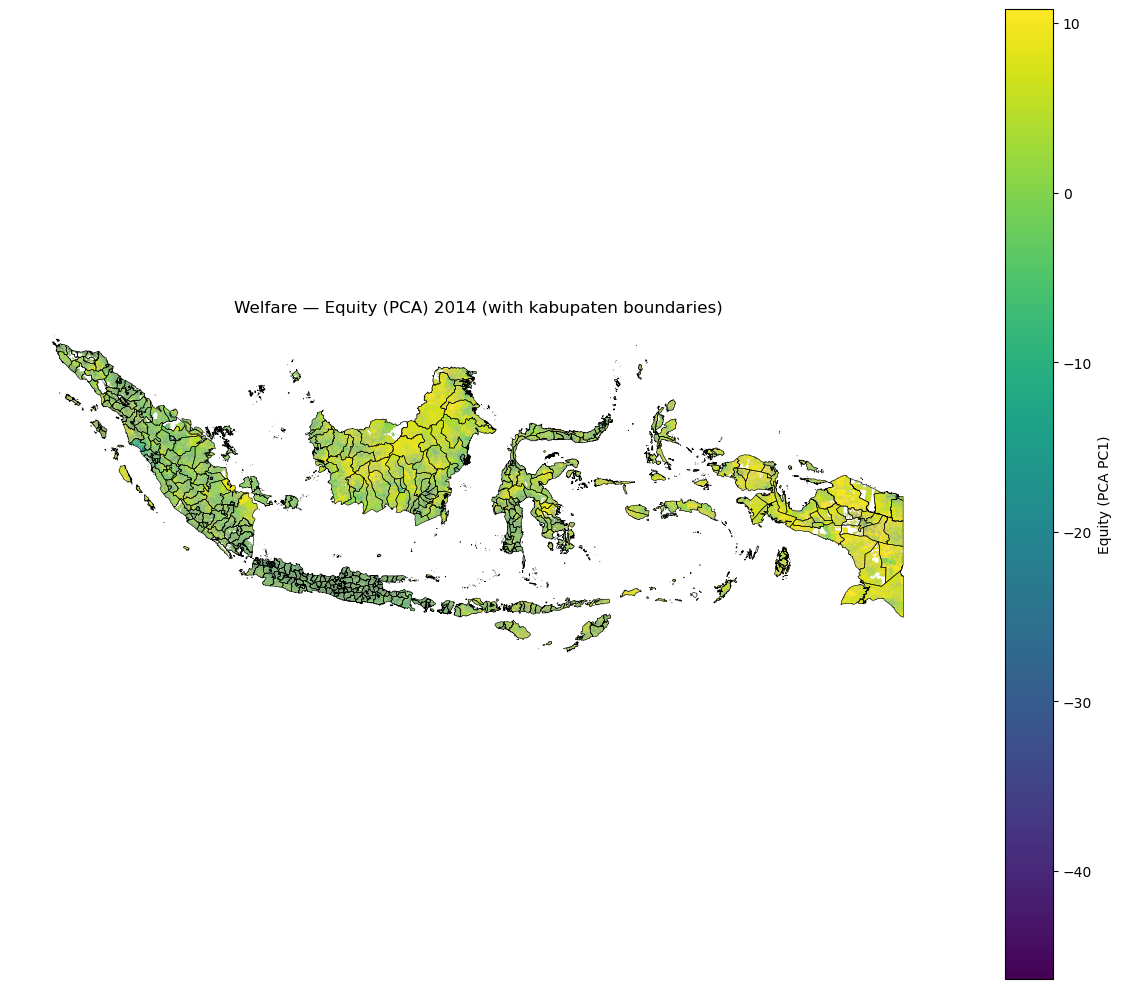

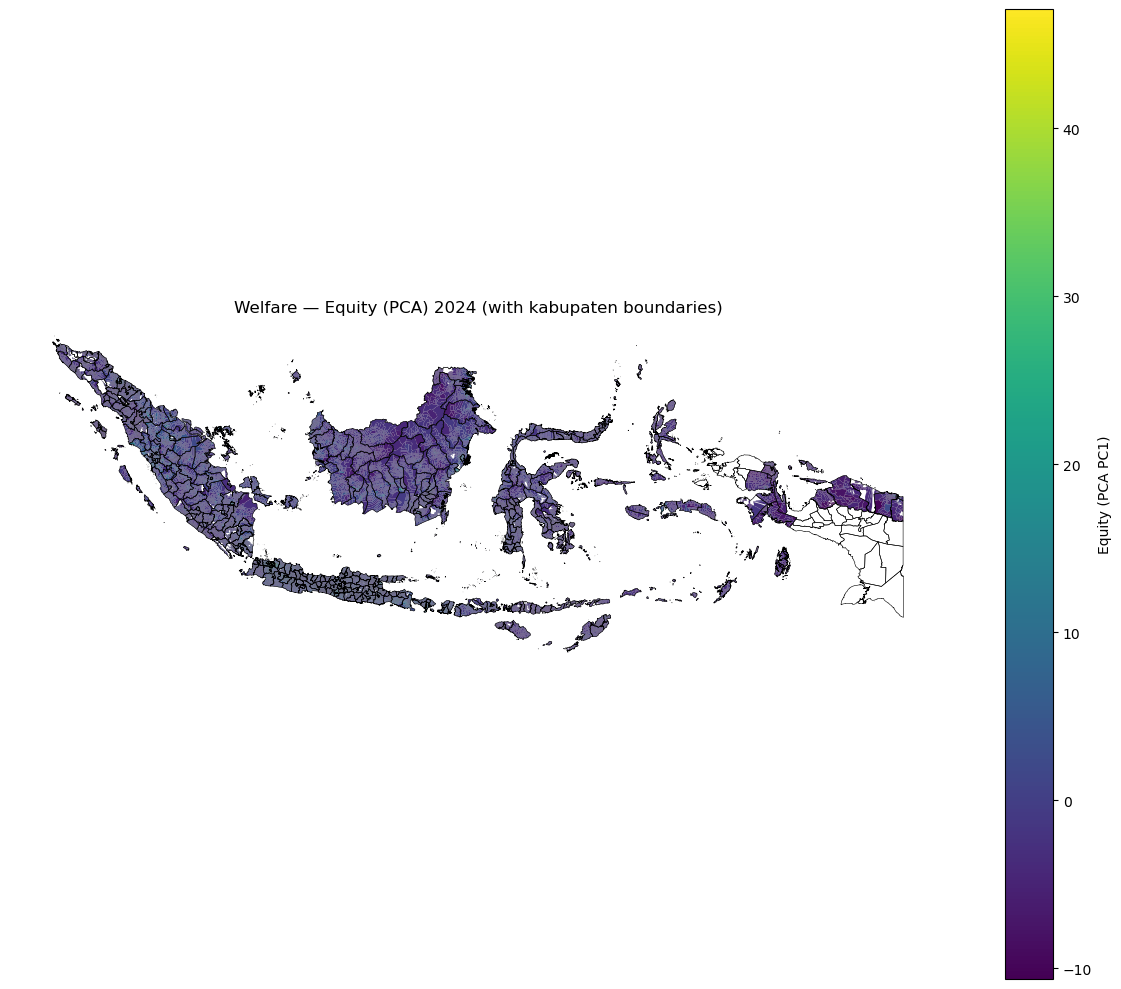

In [8]:
# PCA Equity (P1) — 2014 and 2024 (NaN/missing shown in light gray)
col_p1 = "pca_P1_pc1"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year or col_p1 not in gdf_pca_by_year[year].columns:
        print(f"Lewati {year}: tidak ada PCA P1")
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        print(f"Lewati {year}: tidak ada geometri (gunakan file gpkg untuk peta)")
        continue
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column=col_p1, legend=True, ax=ax, cmap="viridis", linewidth=0.05, edgecolor="gray",
           legend_kwds={"label": "Ekuitas (PCA PC1)"},
           missing_kwds={"color": "lightgray", "label": "Tidak ada data"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Kesejahteraan — Ekuitas (PCA) {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

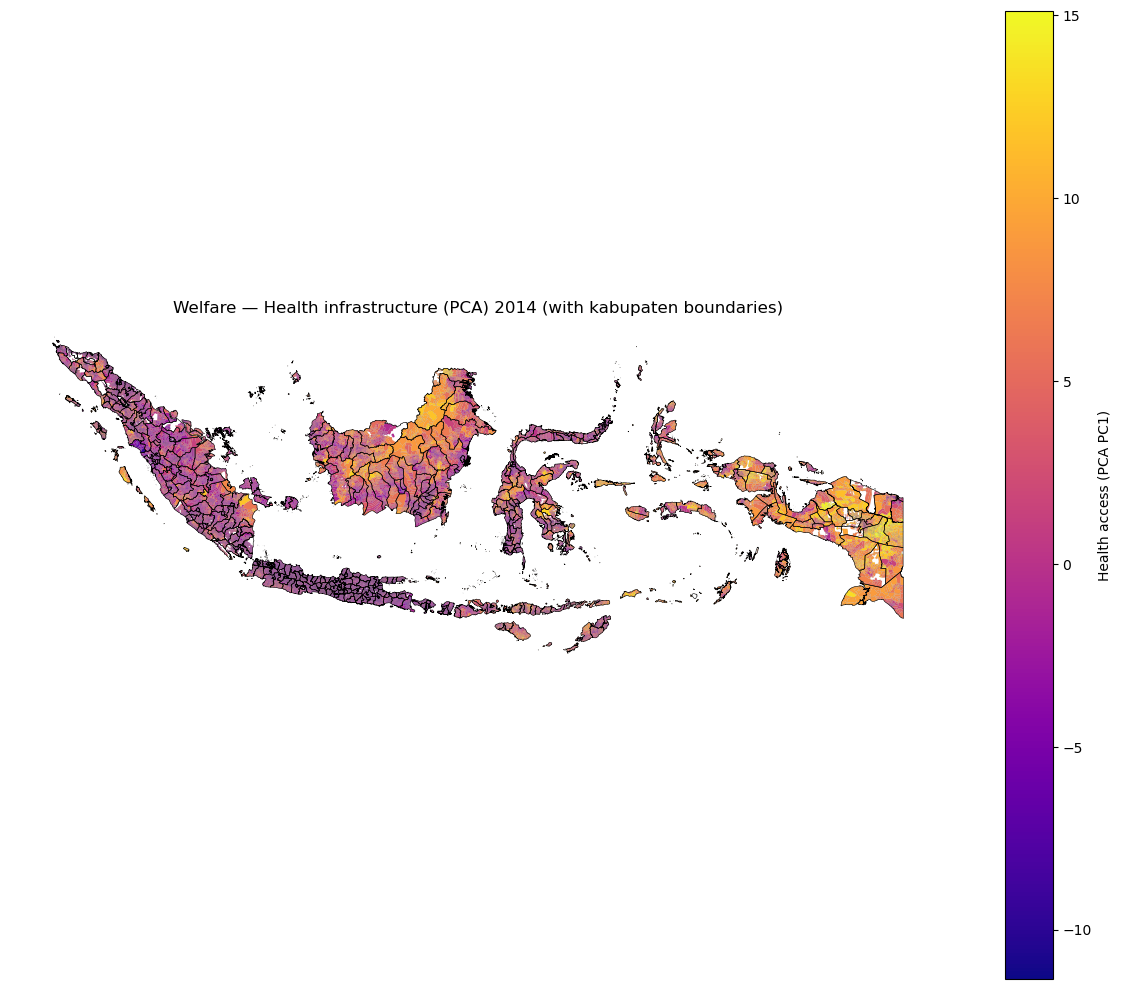

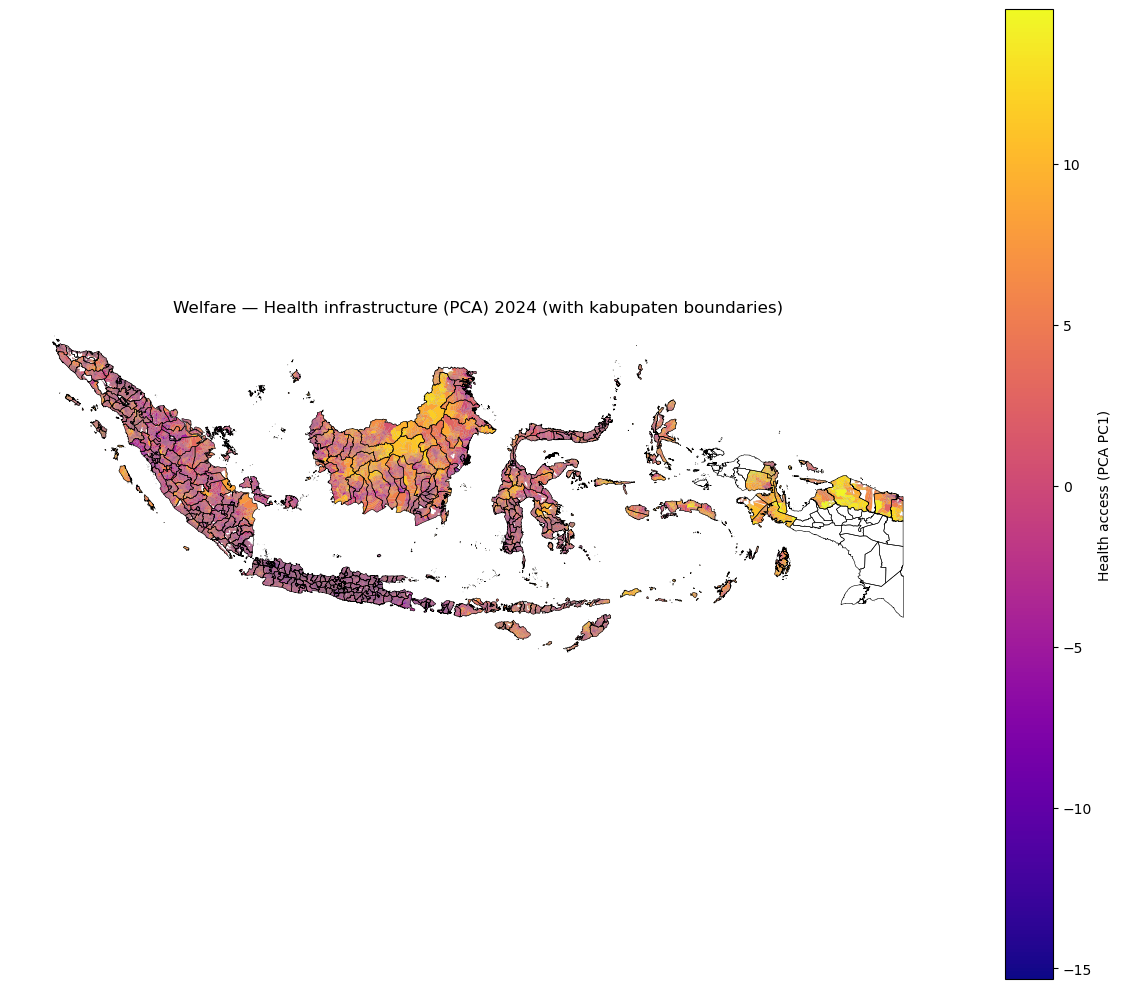

In [9]:
# PCA Health (P2) — 2014 and 2024 (NaN/missing shown in light gray)
col_p2 = "pca_P2_pc1"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year or col_p2 not in gdf_pca_by_year[year].columns:
        print(f"Lewati {year}: tidak ada PCA P2")
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        print(f"Lewati {year}: tidak ada geometri (gunakan file gpkg untuk peta)")
        continue
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column=col_p2, legend=True, ax=ax, cmap="plasma", linewidth=0.05, edgecolor="gray",
           legend_kwds={"label": "Akses kesehatan (PCA PC1)"},
           missing_kwds={"color": "lightgray", "label": "Tidak ada data"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Kesejahteraan — Akses kesehatan (PCA) {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 4. Tabel dan analisis tambahan

Descriptive stats untuk skor PCA per tahun; welfare (Equity & Health) IUP vs non-IUP; ringkasan tingkat provinsi; plus tabel dan grafik tambahan untuk nuansa analisis.

In [10]:
# Table: PCA (Equity & Health) descriptive stats by year
rows = []
for y in sorted(gdf_pca_by_year.keys()):
    g = gdf_pca_by_year[y]
    r = {"year": y}
    for col in ["pca_P1_pc1", "pca_P2_pc1"]:
        if col not in g.columns:
            continue
        v = g[col].dropna()
        r[f"{col}_mean"] = round(v.mean(), 4)
        r[f"{col}_std"] = round(v.std(), 4)
        r[f"{col}_n"] = len(v)
    rows.append(r)
df_pca_stats = pd.DataFrame(rows)
df_pca_stats

,year,pca_P1_pc1_mean,pca_P1_pc1_std,pca_P1_pc1_n,pca_P2_pc1_mean,pca_P2_pc1_std,pca_P2_pc1_n
0,2011,0.0,3.9571,50,-0.0,3.3900,50
1,2014,0.0,3.4885,79681,-0.0,3.6026,79681
2,2018,0.0,4.0466,80822,-0.0,3.5637,80822
3,2019,-0.0,1.9667,80641,0.0,3.4605,80641
4,2020,0.0,3.0925,80466,0.0,3.4407,80466
5,2021,0.0,3.4101,80350,-0.0,4.6464,80350
6,2024,-0.0,3.3339,77123,-0.0,3.2646,77123


In [11]:
# Table: Mean welfare (PCA) by IUP status — 2014 and 2024
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    if "has_iup" not in g.columns or "pca_P1_pc1" not in g.columns:
        continue
    cols = ["pca_P1_pc1", "pca_P2_pc1"]
    cols = [c for c in cols if c in g.columns]
    tab = g.groupby("has_iup")[cols].agg(["mean", "std", "count"]).round(4)
    tab.index = ["No IUP", "Has IUP"]
    print(f"Tahun {year} — Rata-rata (std, jumlah) PCA menurut status IUP:")
    display(tab)
    print()

Year 2014 — Mean (std, count) PCA by IUP status:


pca_P1_pc1                pca_P2_pc1               
              mean     std  count       mean     std  count
No IUP     -0.0504  3.5044  74835    -0.0309  3.6224  74835
Has IUP     0.7788  3.1314   4846     0.4778  3.2458   4846


Year 2024 — Mean (std, count) PCA by IUP status:


pca_P1_pc1                pca_P2_pc1               
              mean     std  count       mean     std  count
No IUP      0.0224  3.3768  72310    -0.0466  3.2641  72310
Has IUP    -0.3367  2.5831   4813     0.7000  3.1914   4813

In [ ]:
# Table: Desa dengan IUP by province — all years (pivot)
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if "has_iup" not in g.columns:
        continue
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else ("ADM1_EN" if "ADM1_EN" in g.columns else None)
    if prov_col is None:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg = agg.rename(columns={prov_col: "NAMA_PROV"})  # standardize for concat/pivot
    agg["year"] = y
    rows.append(agg)
if rows:
    df_prov = pd.concat(rows, ignore_index=True)
    df_prov["pct_iup"] = (100 * df_prov["n_iup"] / df_prov["n_desa"]).round(2)
    pivot_n = df_prov.pivot(index="NAMA_PROV", columns="year", values="n_iup").fillna(0).astype(int)
    pivot_pct = df_prov.pivot(index="NAMA_PROV", columns="year", values="pct_iup")
    print("Jumlah desa dengan IUP per provinsi dan tahun:")
    display(pivot_n)
    print("\n% desa dengan IUP per provinsi dan tahun:")
    display(pivot_pct.round(2))

Number of desa dengan IUP by province and year:


year,2011,2014,2018,2019,2020,2021,2024
NAMA_PROV,,,,,,,
ACEH,0,0,0,0,0,0,61
Aceh,0,61,61,62,62,61,0
BALI,0,0,0,0,0,0,1
BANTEN,15,0,0,0,0,0,83
BENGKULU,6,0,0,0,0,0,116
...,...,...,...,...,...,...,...
Sulawesi Tenggara,0,219,254,247,248,246,0
Sulawesi Utara,0,120,121,120,119,121,0
Sumatera Barat,0,86,87,87,87,87,0



% desa dengan IUP by province and year:


year,2011,2014,2018,2019,2020,2021,2024
NAMA_PROV,,,,,,,
ACEH,NaN,NaN,NaN,NaN,NaN,NaN,0.94
Aceh,NaN,0.93,0.93,0.94,0.94,0.93,NaN
BALI,NaN,NaN,NaN,NaN,NaN,NaN,0.14
BANTEN,2.68,NaN,NaN,NaN,NaN,NaN,5.35
BENGKULU,40.00,NaN,NaN,NaN,NaN,NaN,7.72
...,...,...,...,...,...,...,...
Sulawesi Tenggara,NaN,9.36,10.85,10.56,10.60,10.51,NaN
Sulawesi Utara,NaN,6.53,6.58,6.53,6.47,6.58,NaN
Sumatera Barat,NaN,7.38,7.47,7.47,7.47,7.47,NaN


In [15]:
# Table: IUP intensity (among desa with IUP) — n_wiup, area_hectares_iup, pct_iup_coverage by year
iup_intensity_cols = ["n_wiup", "area_hectares_iup", "pct_iup_coverage"]
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    with_iup = g[g["has_iup"] == 1] if "has_iup" in g.columns else g
    if len(with_iup) == 0:
        continue
    r = {"year": y, "n_desa_with_iup": len(with_iup)}
    for c in iup_intensity_cols:
        if c in with_iup.columns:
            r[f"{c}_mean"] = round(with_iup[c].mean(), 2)
            r[f"{c}_median"] = round(with_iup[c].median(), 2)
    rows.append(r)
pd.DataFrame(rows)

,year,n_desa_with_iup,n_wiup_mean,n_wiup_median,area_hectares_iup_mean,area_hectares_iup_median,pct_iup_coverage_mean,pct_iup_coverage_median
0,2011,880,4.02,2.0,697.91,25.84,11.64,2.38
1,2014,4846,2.94,2.0,579.52,44.62,9.77,2.64
2,2018,4902,2.94,2.0,578.75,45.18,9.84,2.73
3,2019,4853,2.96,2.0,585.22,45.22,9.79,2.69
4,2020,4856,2.96,2.0,576.10,45.23,9.92,2.69
5,2021,4830,2.97,2.0,587.31,44.58,9.86,2.69
6,2024,4813,2.95,2.0,572.86,44.60,9.91,2.73


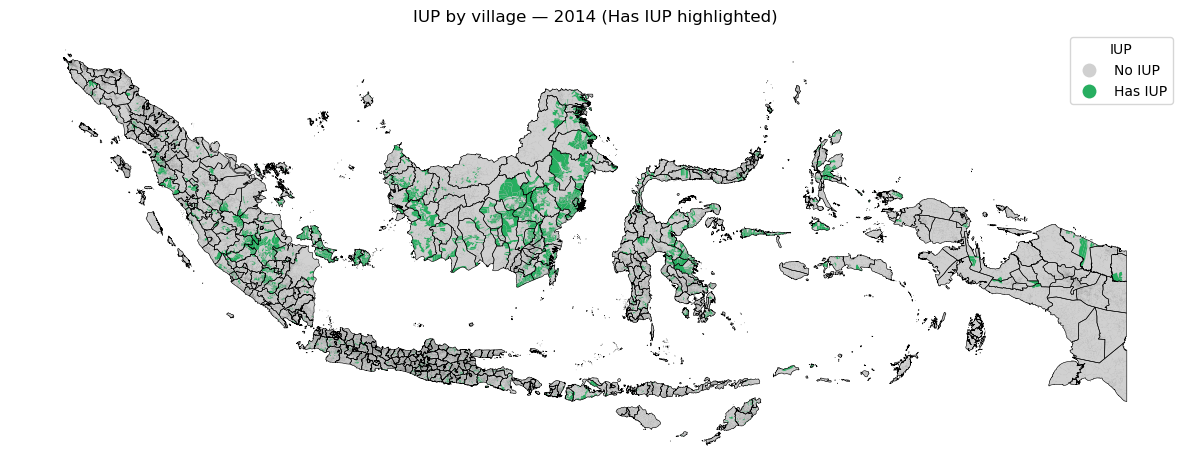

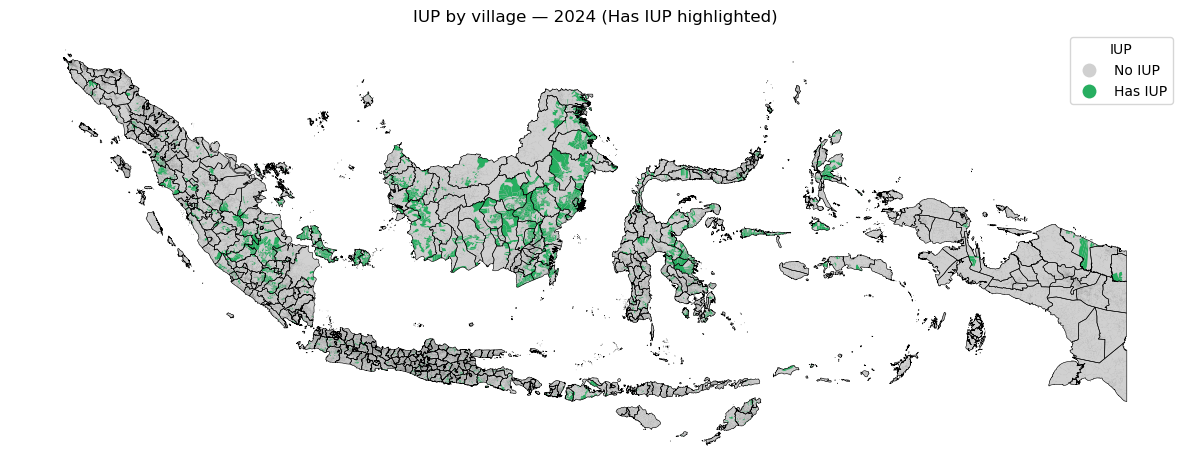

In [16]:
# Variation: IUP map — only highlight desa WITH IUP (others in light gray), 2014 and 2024
from matplotlib.colors import ListedColormap
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    g["iup_plot"] = g["has_iup"].fillna(0).map({0: "No IUP", 1: "Has IUP"})
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = ListedColormap(["#d0d0d0", "#27ae60"])
    g.plot(column="iup_plot", categorical=True, legend=True, ax=ax,
           cmap=cmap, categories=["No IUP", "Has IUP"],
           linewidth=0.05, edgecolor="gray", legend_kwds={"title": "IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (desa dengan IUP ditandai)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Top provinces (desa dengan IUP) & welfare by IUP status

Bar chart: 15 provinsi dengan desa IUP terbanyak (2014 & 2024). Boxplot: distribusi skor Equity/Health (PCA) untuk desa dengan vs tanpa IUP — memberi nuansa apakah wilayah IUP sistematis berbeda dalam welfare.

In [ ]:
# Bar chart: top 15 provinces by number of desa dengan IUP (2014 and 2024)
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else "ADM1_EN"
    if prov_col not in g.columns or "has_iup" not in g.columns:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg = agg.sort_values("n_iup", ascending=False).head(15)
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.barh(range(len(agg)), agg["n_iup"], color="steelblue", alpha=0.8)
    ax.set_yticks(range(len(agg)))
    ax.set_yticklabels(agg[prov_col], fontsize=9)
    ax.set_xlabel("Jumlah desa dengan IUP")
    ax.set_title(f"Top 15 provinsi — desa dengan IUP ({year})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Boxplot: welfare (PCA Equity & Health) by IUP status — 2014 and 2024
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    if "has_iup" not in g.columns or "pca_P1_pc1" not in g.columns:
        continue
    df_bp = g[["has_iup", "pca_P1_pc1"]].copy()
    if "pca_P2_pc1" in g.columns:
        df_bp["pca_P2_pc1"] = g["pca_P2_pc1"]
    df_bp["IUP"] = df_bp["has_iup"].map({0: "Tanpa IUP", 1: "Dengan IUP"})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    df_bp.boxplot(column="pca_P1_pc1", by="IUP", ax=ax1)
    ax1.set_title(f"Equity (PCA P1) by IUP — {year}")
    ax1.set_ylabel("Skor PCA")
    if "pca_P2_pc1" in df_bp.columns:
        df_bp.boxplot(column="pca_P2_pc1", by="IUP", ax=ax2)
        ax2.set_title(f"Health (PCA P2) by IUP — {year}")
        ax2.set_ylabel("Skor PCA")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [ ]:
# Histogram: distribusi area IUP (ha) — desa dengan IUP saja, 2014 dan 2024
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, year in zip([ax1, ax2], [2014, 2024]):
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    if "area_hectares_iup" not in g.columns or "has_iup" not in g.columns:
        continue
    wiup = g[g["has_iup"] == 1]["area_hectares_iup"].dropna()
    if len(wiup) == 0:
        continue
    ax.hist(wiup.clip(upper=wiup.quantile(0.98)), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Area IUP (ha)")
    ax.set_ylabel("Jumlah desa")
    ax.set_title(f"Distribusi area IUP — {year} (desa dengan IUP, top 98%)")
plt.tight_layout()
plt.show()

In [ ]:
# Line chart: desa dengan IUP and % IUP over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df = df_desa_iup_by_year.sort_values("year")
ax1.bar(df["year"], df["desa_dengan_IUP"], color="steelblue", edgecolor="navy", alpha=0.8)
ax1.set_ylabel("Jumlah desa dengan IUP")
ax1.set_title("Desa dengan IUP per tahun")
ax2.plot(df["year"], df["pct_desa_IUP"], marker="o", color="coral", linewidth=2, markersize=8)
ax2.set_ylabel("% desa dengan IUP")
ax2.set_title("Persentase desa dengan IUP per tahun")
ax2.set_xlabel("Tahun")
plt.tight_layout()
plt.show()

In [ ]:
# Line chart: mean welfare (PCA) by year — Equity & Health
if "df_pca_stats" in dir() and df_pca_stats is not None and len(df_pca_stats) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(df_pca_stats["year"], df_pca_stats["pca_P1_pc1_mean"], marker="o", label="Equity (P1 PC1)", linewidth=2)
    if "pca_P2_pc1_mean" in df_pca_stats.columns:
        ax.plot(df_pca_stats["year"], df_pca_stats["pca_P2_pc1_mean"], marker="s", label="Health (P2 PC1)", linewidth=2)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.set_ylabel("Mean PCA score")
    ax.set_xlabel("Tahun")
    ax.set_title("Rata-rata skor welfare (PCA) per tahun")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Jalankan cell tabel PCA stats terlebih dahulu.")

In [ ]:
# Table: distribusi area IUP (ha) — hanya desa dengan IUP, by year
area_rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if "area_hectares_iup" not in g.columns or "has_iup" not in g.columns:
        continue
    wiup = g[g["has_iup"] == 1]["area_hectares_iup"].dropna()
    if len(wiup) == 0:
        continue
    area_rows.append({
        "year": y,
        "n_desa_dengan_IUP": len(wiup),
        "area_ha_min": round(wiup.min(), 2),
        "area_ha_max": round(wiup.max(), 2),
        "area_ha_mean": round(wiup.mean(), 2),
        "area_ha_median": round(wiup.median(), 2),
    })
if area_rows:
    df_area_iup = pd.DataFrame(area_rows)
    print("Distribusi area_hectares_iup (desa dengan IUP):")
    display(df_area_iup)
else:
    print("Tidak ada data area_hectares_iup.")

In [17]:
# Summary: all years — n_desa, desa dengan IUP, and PCA coverage in one table
summary_rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year.get(y)
    gpc = gdf_pca_by_year.get(y)
    r = {"year": y}
    if g is not None:
        r["n_desa"] = len(g)
        r["desa_dengan_IUP"] = int(g["has_iup"].fillna(0).sum()) if "has_iup" in g.columns else None
        r["pct_IUP"] = round(100 * r["desa_dengan_IUP"] / r["n_desa"], 2) if r["desa_dengan_IUP"] is not None else None
    if gpc is not None:
        for col in ["pca_P1_pc1", "pca_P2_pc1"]:
            if col in gpc.columns:
                r[f"n_valid_{col}"] = gpc[col].notna().sum()
    summary_rows.append(r)
df_summary_all = pd.DataFrame(summary_rows)
df_summary_all

,year,n_desa,desa_dengan_IUP,pct_IUP,n_valid_pca_P1_pc1,n_valid_pca_P2_pc1
0,2011,83862,880,1.05,50,50
1,2014,81912,4846,5.92,79681,79681
2,2018,81912,4902,5.98,80822,80822
3,2019,81912,4853,5.92,80641,80641
4,2020,81912,4856,5.93,80466,80466
5,2021,81912,4830,5.90,80350,80350
6,2024,81912,4813,5.88,77123,77123


### Smelter — descriptive stats

Ringkasan jumlah desa terdampak smelter per tahun (Regimen 1 & 2), per provinsi, dan daftar lokasi dari **Data Smelter Indonesia.xlsx**. Ditambah: overlap IUP–smelter dan rata-rata welfare (Equity/Health PCA) menurut status smelter. *(Panel dan daftar smelter di-load di cell berikutnya.)*

In [ ]:
# Load smelter panel and list (required for smelter stats below and for Section 5 maps)
PANEL_SMELTER_PATH = DATA_BERSIH / "panel_PCA_with_smelter.csv"
SMELTER_XLSX = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Data Smelter Indonesia.xlsx")
panel_smelter = None
if PANEL_SMELTER_PATH.exists():
    panel_smelter = pd.read_csv(PANEL_SMELTER_PATH)
    print("Panel dengan smelter:", panel_smelter.shape, "| reg1:", panel_smelter["smelter_reg1"].sum(), "| reg2:", panel_smelter["smelter_reg2"].sum())
else:
    print("File panel_PCA_with_smelter.csv tidak ditemukan; jalankan cleaning2 dulu.")
smelter_df = None
if SMELTER_XLSX.exists():
    smelter_df = pd.read_excel(SMELTER_XLSX, sheet_name="Sheet1")
    print("Jumlah baris smelter:", len(smelter_df))

In [ ]:
# Smelter descriptive stats — desa dengan smelter by year (Regimen 1 & 2)
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    smelter_by_year = panel_smelter.groupby("year").agg(
        n_desa=("smelter_reg1", "count"),
        n_smelter_reg1=("smelter_reg1", "sum"),
        n_smelter_reg2=("smelter_reg2", "sum"),
    ).reset_index()
    smelter_by_year["pct_reg1"] = (100 * smelter_by_year["n_smelter_reg1"] / smelter_by_year["n_desa"]).round(2)
    smelter_by_year["pct_reg2"] = (100 * smelter_by_year["n_smelter_reg2"] / smelter_by_year["n_desa"]).round(2)
    print("Jumlah desa dengan smelter per tahun:")
    display(smelter_by_year)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    x = smelter_by_year["year"]
    ax.bar(x - 0.2, smelter_by_year["n_smelter_reg1"], width=0.35, label="Regimen 1 (campuran)", color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, smelter_by_year["n_smelter_reg2"], width=0.35, label="Regimen 2 (full kecamatan)", color="coral", alpha=0.8)
    ax.set_ylabel("Jumlah desa")
    ax.set_xlabel("Tahun")
    ax.set_title("Desa terdampak smelter per tahun")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Panel smelter tidak ada; jalankan cell load panel di atas.")

In [ ]:
# Smelter by province (year 2024) and list of smelter locations
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    prov_col = "NAMA_PROV" if "NAMA_PROV" in panel_smelter.columns else "ADM1_EN"
    if prov_col in panel_smelter.columns:
        sub = panel_smelter[panel_smelter["year"] == 2024]
        agg = sub.groupby(prov_col).agg(n_desa=("smelter_reg1", "count"), n_smelter_r1=("smelter_reg1", "sum"), n_smelter_r2=("smelter_reg2", "sum")).reset_index()
        agg = agg[agg["n_smelter_r1"] > 0].sort_values("n_smelter_r1", ascending=False)
        print("Provinsi dengan desa terdampak smelter (2024) — Regimen 1 & 2:")
        display(agg.head(15))
if smelter_df is not None and len(smelter_df) > 0:
    print("\nDaftar lokasi smelter (Data Smelter Indonesia.xlsx) — 15 baris pertama:")
    display(smelter_df.head(15))

In [ ]:
# Overlap IUP–smelter: desa that have both IUP and smelter (Regimen 1 & 2) by year
# Mean welfare (PCA) by smelter status (Regimen 1) by year
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
    overlap_rows = []
    for y in sorted(panel_smelter["year"].unique()):
        sub = panel_smelter[panel_smelter["year"] == y]
        n = len(sub)
        n_r1 = sub["smelter_reg1"].sum()
        n_r2 = sub["smelter_reg2"].sum()
        if "has_iup" in sub.columns:
            n_iup = sub["has_iup"].fillna(0).sum()
            n_both_r1 = ((sub["smelter_reg1"] == 1) & (sub["has_iup"] == 1)).sum()
            n_both_r2 = ((sub["smelter_reg2"] == 1) & (sub["has_iup"] == 1)).sum()
            overlap_rows.append({"year": y, "n_desa": n, "n_IUP": n_iup, "n_smelter_r1": n_r1, "n_smelter_r2": n_r2,
                                "n_IUP_dan_smelter_r1": n_both_r1, "n_IUP_dan_smelter_r2": n_both_r2})
        else:
            overlap_rows.append({"year": y, "n_desa": n, "n_smelter_r1": n_r1, "n_smelter_r2": n_r2})
    if overlap_rows:
        df_overlap = pd.DataFrame(overlap_rows)
        print("Overlap IUP & smelter per tahun (desa yang punya IUP dan terdampak smelter):")
        display(df_overlap)

    # Mean welfare (Equity & Health PCA) by smelter status (Regimen 1) by year
    if "pca_P1_pc1" in panel_smelter.columns:
        welf_rows = []
        for y in sorted(panel_smelter["year"].unique()):
            sub = panel_smelter[panel_smelter["year"] == y]
            for reg in [0, 1]:
                s = sub[sub["smelter_reg1"] == reg]
                if len(s) == 0:
                    continue
                r = {"year": y, "smelter_reg1": "Ya" if reg == 1 else "Tidak", "n_desa": len(s)}
                if "pca_P1_pc1" in s.columns:
                    r["mean_Equity_P1"] = round(s["pca_P1_pc1"].mean(), 4)
                    r["std_Equity_P1"] = round(s["pca_P1_pc1"].std(), 4)
                if "pca_P2_pc1" in s.columns:
                    r["mean_Health_P2"] = round(s["pca_P2_pc1"].mean(), 4)
                    r["std_Health_P2"] = round(s["pca_P2_pc1"].std(), 4)
                welf_rows.append(r)
        if welf_rows:
            df_welf_smelter = pd.DataFrame(welf_rows)
            print("\nRata-rata welfare (PCA) menurut status smelter Regimen 1 per tahun:")
            display(df_welf_smelter)
else:
    print("Panel smelter tidak ada; jalankan cell load panel di atas.")

## 5. Peta intervensi smelter

Data: **Data Smelter Indonesia.xlsx** (kecamatan-level; semua desa di kecamatan terdampak).  
Panel dengan flag: **panel_PCA_with_smelter.csv** dari cleaning2 (smelter_reg1 = campuran, smelter_reg2 = full kecamatan).  
Peta: desa dengan intervensi smelter (Regimen 1 & 2) untuk 2014 dan 2024.

In [ ]:
# Load smelter panel (from cleaning2) for mapping. (Also loaded in Section 4; run this if you run Section 5 only.)
PANEL_SMELTER_PATH = DATA_BERSIH / "panel_PCA_with_smelter.csv"
SMELTER_XLSX = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Data Smelter Indonesia.xlsx")
panel_smelter = None
if PANEL_SMELTER_PATH.exists():
    panel_smelter = pd.read_csv(PANEL_SMELTER_PATH)
    print("Panel dengan smelter:", panel_smelter.shape, "| jumlah reg1:", panel_smelter["smelter_reg1"].sum(), "| jumlah reg2:", panel_smelter["smelter_reg2"].sum())
else:
    print("File panel_PCA_with_smelter.csv tidak ditemukan; jalankan cleaning2 dulu.")
smelter_df = None
if SMELTER_XLSX.exists():
    smelter_df = pd.read_excel(SMELTER_XLSX, sheet_name="Sheet1")
    print("Jumlah baris smelter:", len(smelter_df))

In [ ]:
# Smelter map — Regimen 1 (campuran: desa or whole kecamatan) 2014 and 2024
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
    for year in [2014, 2024]:
        if year not in gdf_pca_by_year:
            continue
        g = gdf_pca_by_year[year].copy()
        if not hasattr(g, "geometry") or g.geometry is None:
            continue
        gid = "id_desa_numeric" if "id_desa_numeric" in g.columns else ("id_desa" if "id_desa" in g.columns else "ID_DESA")
        sub = panel_smelter.loc[panel_smelter["year"] == year, [id_panel, "smelter_reg1"]].drop_duplicates(id_panel)
        g = g.merge(sub, left_on=gid, right_on=id_panel, how="left")
        g["smelter_reg1"] = g["smelter_reg1"].fillna(0).astype(int)
        if g.crs is None:
            g.set_crs(4326, inplace=True)
        by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
        admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
        admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        g.plot(column="smelter_reg1", categorical=True, legend=True, ax=ax, cmap="RdYlGn", categories=[0, 1],
               legend_kwds={"title": "Smelter (Regimen 1)", "labels": ["Tidak", "Ya"]}, linewidth=0.05, edgecolor="gray")
        admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
        ax.set_title(f"Intervensi smelter — Regimen 1 (campuran) {year}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Tidak ada panel_smelter atau smelter_reg1; jalankan cleaning2.")

In [ ]:
# Smelter map — Regimen 2 (full kecamatan) 2014 and 2024
if panel_smelter is not None and "smelter_reg2" in panel_smelter.columns:
    id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
    for year in [2014, 2024]:
        if year not in gdf_pca_by_year:
            continue
        g = gdf_pca_by_year[year].copy()
        if not hasattr(g, "geometry") or g.geometry is None:
            continue
        gid = "id_desa_numeric" if "id_desa_numeric" in g.columns else ("id_desa" if "id_desa" in g.columns else "ID_DESA")
        sub = panel_smelter.loc[panel_smelter["year"] == year, [id_panel, "smelter_reg2"]].drop_duplicates(id_panel)
        g = g.merge(sub, left_on=gid, right_on=id_panel, how="left")
        g["smelter_reg2"] = g["smelter_reg2"].fillna(0).astype(int)
        if g.crs is None:
            g.set_crs(4326, inplace=True)
        by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
        admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
        admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        g.plot(column="smelter_reg2", categorical=True, legend=True, ax=ax, cmap="RdYlGn", categories=[0, 1],
               legend_kwds={"title": "Smelter (Regimen 2)", "labels": ["Tidak", "Ya"]}, linewidth=0.05, edgecolor="gray")
        admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
        ax.set_title(f"Intervensi smelter — Regimen 2 (seluruh kecamatan) {year}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Tidak ada panel_smelter atau smelter_reg2; jalankan cleaning2.")